In [1]:
!pip install -q lpips torchmetrics

import torch, random, os
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPU = torch.cuda.device_count()
print("GPUs:", N_GPU)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
GPUs: 2


In [2]:
class SRDataset(Dataset):
    def __init__(self, root):
        self.paths = list(Path(root).rglob("*.png"))
        self.t = T.Compose([
            T.Resize(128),
            T.CenterCrop(128),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        hr = self.t(img)

        lr = TF.resize(img, 24)
        lr = self.t(lr)

        lr_up = TF.resize(img, 128)
        lr_up = self.t(lr_up)

        return hr, lr, lr_up

dataset = SRDataset("/kaggle/input/datasets/joe1995/div2k-dataset")
loader = DataLoader(dataset, batch_size=8*N_GPU, shuffle=True)

In [3]:
class DiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(6,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,3,3,1,1)
        )

    def forward(self,x):
        return self.net(x)

diff_model = DiffusionNet().to(DEVICE)
if N_GPU>1: diff_model = nn.DataParallel(diff_model)

opt_diff = torch.optim.Adam(diff_model.parameters(),1e-4)

In [4]:
for epoch in range(20):
    for hr, lr, lr_up in loader:
        hr = hr.to(DEVICE)
        lr_up = lr_up.to(DEVICE)

        noise = torch.randn_like(hr)

        # input: noise + condition
        inp = torch.cat([noise, lr_up], 1)

        # model predicts HR directly
        pred = diff_model(inp)

        loss = F.mse_loss(pred, hr)

        opt_diff.zero_grad()
        loss.backward()
        opt_diff.step()

    print("Diffusion Epoch:", epoch, loss.item())

Diffusion Epoch: 0 0.024610143154859543
Diffusion Epoch: 1 0.014742176048457623
Diffusion Epoch: 2 0.011300778016448021
Diffusion Epoch: 3 0.007314278744161129
Diffusion Epoch: 4 0.006730139255523682
Diffusion Epoch: 5 0.004597389604896307
Diffusion Epoch: 6 0.003817512420937419
Diffusion Epoch: 7 0.004110394045710564
Diffusion Epoch: 8 0.002916495082899928
Diffusion Epoch: 9 0.002818478737026453
Diffusion Epoch: 10 0.004016547463834286
Diffusion Epoch: 11 0.002127911662682891
Diffusion Epoch: 12 0.0018042675219476223
Diffusion Epoch: 13 0.0017662647878751159
Diffusion Epoch: 14 0.001431577606126666
Diffusion Epoch: 15 0.0018276551272720098
Diffusion Epoch: 16 0.0014762866776436567
Diffusion Epoch: 17 0.0019957530312240124
Diffusion Epoch: 18 0.001091556390747428
Diffusion Epoch: 19 0.0016160381492227316


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,3,3,1,1),
            nn.Tanh()
        )
    def forward(self,x): return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,3,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128,1,3,1,1)
        )
    def forward(self,x): return self.net(x)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

if N_GPU>1:
    G = nn.DataParallel(G)
    D = nn.DataParallel(D)

optG = torch.optim.Adam(G.parameters(), lr=5e-5)
optD = torch.optim.Adam(D.parameters(), lr=5e-5)

adv = nn.BCEWithLogitsLoss()

In [6]:
from torchvision.models import vgg19, VGG19_Weights

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features[:36].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg.to(DEVICE)

    def forward(self, x, y):
        # convert from [-1,1] → [0,1]
        x = (x + 1) / 2
        y = (y + 1) / 2
        return F.mse_loss(self.vgg(x), self.vgg(y))

perceptual_loss = VGGPerceptualLoss()

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 217MB/s]  


In [7]:
diff_model.eval()

for epoch in range(20):
    for hr, lr, lr_up in loader:
        hr = hr.to(DEVICE)
        lr_up = lr_up.to(DEVICE)

        # diffusion output (frozen)
        with torch.no_grad():
            noise = torch.randn_like(hr)
            diff_out = diff_model(torch.cat([noise, lr_up], 1))

        fake = G(diff_out)


        d_real = D(hr)
        d_fake = D(fake.detach())

        real_lbl = torch.ones_like(d_real)
        fake_lbl = torch.zeros_like(d_fake)

        lossD = (adv(d_real, real_lbl) + adv(d_fake, fake_lbl)) / 2

        optD.zero_grad()
        lossD.backward()
        optD.step()


        fake = G(diff_out)
        d_fake = D(fake)

        loss_pixel = F.l1_loss(fake, hr)
        loss_perc = perceptual_loss(fake, hr)
        loss_adv = adv(d_fake, real_lbl)

        lossG = (
            1.0 * loss_pixel +
            0.005 * loss_perc +
            5e-4 * loss_adv
        )

        optG.zero_grad()
        lossG.backward()
        optG.step()

    print(f"Epoch {epoch} | G: {lossG.item():.4f} | D: {lossD.item():.4f}")

Epoch 0 | G: 0.0993 | D: 0.6896
Epoch 1 | G: 0.0676 | D: 0.6841
Epoch 2 | G: 0.0577 | D: 0.6854
Epoch 3 | G: 0.0498 | D: 0.6825
Epoch 4 | G: 0.0442 | D: 0.6864
Epoch 5 | G: 0.0466 | D: 0.6798
Epoch 6 | G: 0.0441 | D: 0.6852
Epoch 7 | G: 0.0439 | D: 0.6742
Epoch 8 | G: 0.0501 | D: 0.6672
Epoch 9 | G: 0.0377 | D: 0.6781
Epoch 10 | G: 0.0386 | D: 0.6751
Epoch 11 | G: 0.0448 | D: 0.6593
Epoch 12 | G: 0.0354 | D: 0.6691
Epoch 13 | G: 0.0358 | D: 0.6670
Epoch 14 | G: 0.0424 | D: 0.6747
Epoch 15 | G: 0.0344 | D: 0.6760
Epoch 16 | G: 0.0438 | D: 0.6441
Epoch 17 | G: 0.0307 | D: 0.6703
Epoch 18 | G: 0.0388 | D: 0.6552
Epoch 19 | G: 0.0347 | D: 0.6505


GAN range: -0.8195671439170837 0.7934986352920532


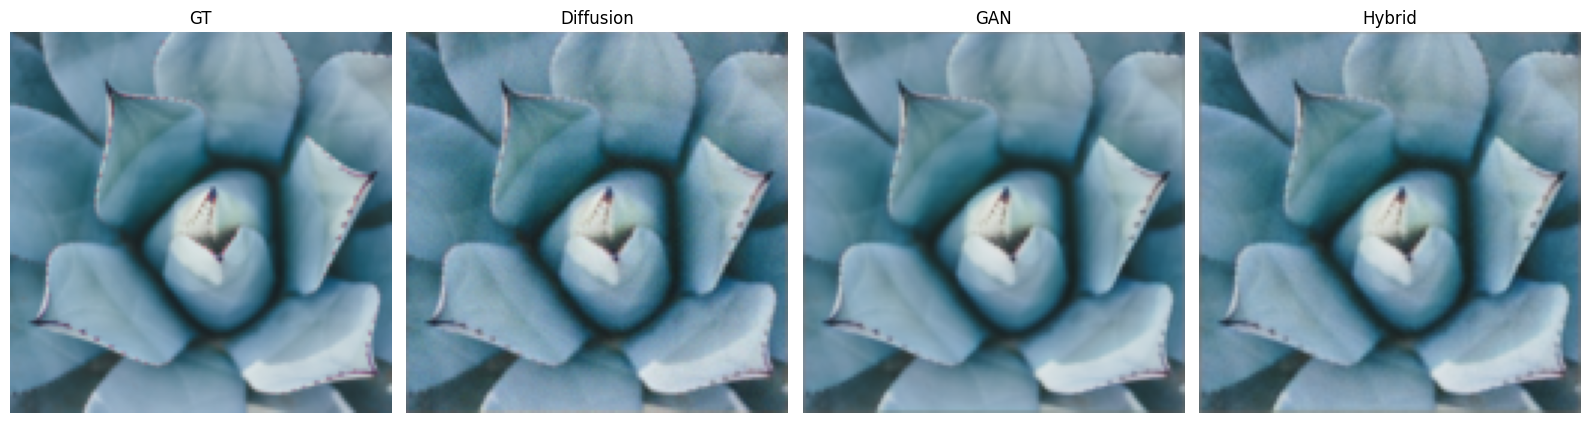

In [8]:
def to_img(x):
    x = x.detach().clamp(-1,1)
    x = (x + 1) / 2
    return x.permute(1,2,0).cpu().numpy()

hr, lr, lr_up = dataset[0]

hr_t = hr.unsqueeze(0).to(DEVICE)
lr_up_t = lr_up.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    noise = torch.randn_like(hr_t)

    diff_out = diff_model(torch.cat([noise, lr_up_t], 1))
    gan_out = G(lr_up_t)
    hybrid_out = G(diff_out)

    print("GAN range:", gan_out.min().item(), gan_out.max().item())

fig, ax = plt.subplots(1, 4, figsize=(16,5))

ax[0].imshow(to_img(hr))
ax[0].set_title("GT")

ax[1].imshow(to_img(diff_out[0]))
ax[1].set_title("Diffusion")

ax[2].imshow(to_img(gan_out[0]))
ax[2].set_title("GAN")

ax[3].imshow(to_img(hybrid_out[0]))
ax[3].set_title("Hybrid")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

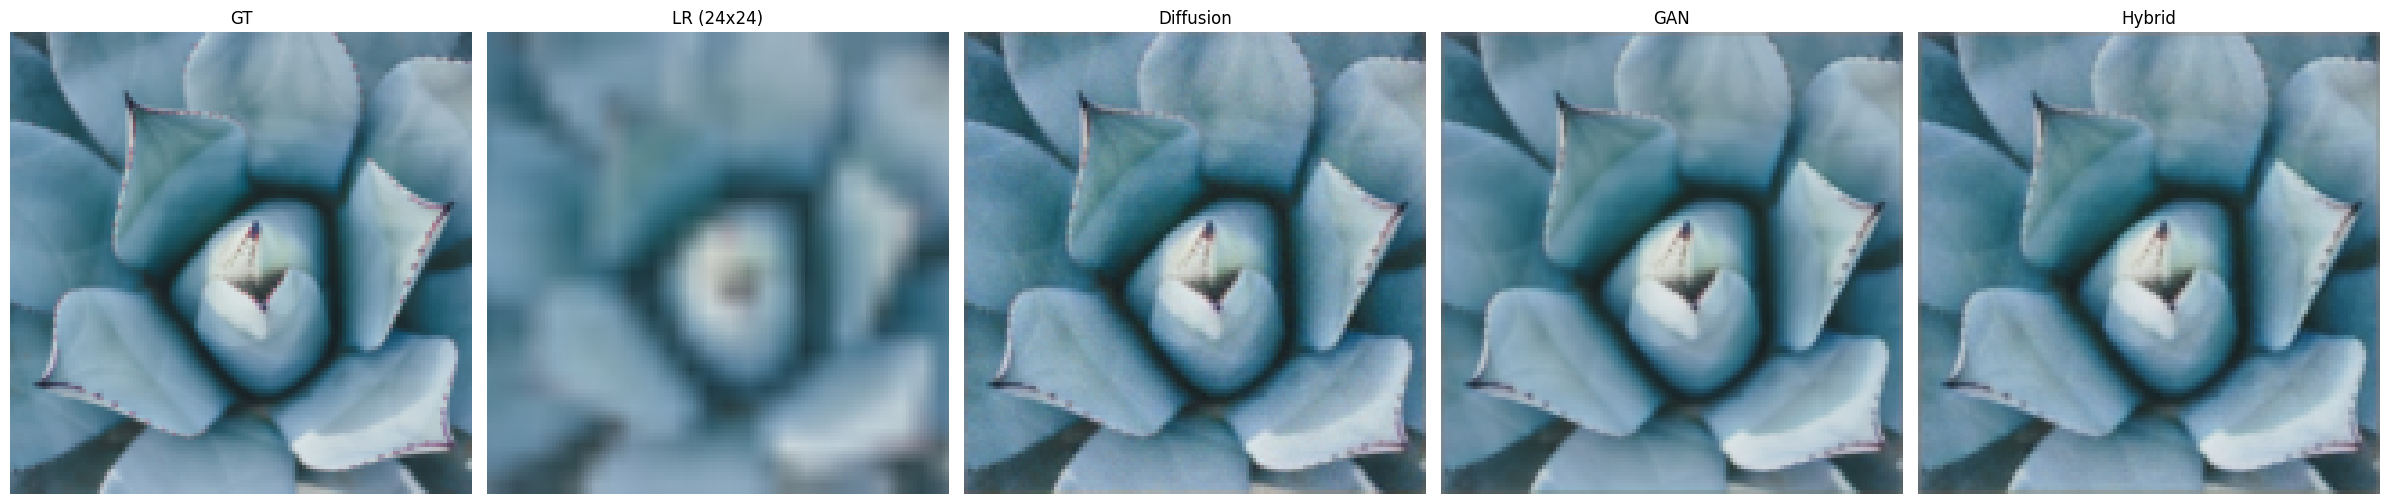

In [9]:
def to_img(x):
    x = x.detach().clamp(-1,1)
    x = (x + 1) / 2
    return x.permute(1,2,0).cpu().numpy()

hr, lr, lr_up = dataset[0]

hr_t = hr.unsqueeze(0).to(DEVICE)
lr_up_t = lr_up.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    noise = torch.randn_like(hr_t)

    diff_out = diff_model(torch.cat([noise, lr_up_t], 1))
    gan_out = G(lr_up_t)
    hybrid_out = G(diff_out)

fig, ax = plt.subplots(1, 5, figsize=(24,5))

# Ground Truth
ax[0].imshow(to_img(hr))
ax[0].set_title("GT")

# Low Resolution (true 24x24)
ax[1].imshow(to_img(lr))
ax[1].set_title("LR (24x24)")

# Diffusion
ax[2].imshow(to_img(diff_out[0]))
ax[2].set_title("Diffusion")

# GAN
ax[3].imshow(to_img(gan_out[0]))
ax[3].set_title("GAN")

# Hybrid
ax[4].imshow(to_img(hybrid_out[0]))
ax[4].set_title("Hybrid")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [10]:
!pip install -q torchmetrics lpips

In [11]:
import torch
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import lpips

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
lpips_metric = lpips.LPIPS(net='alex').to(DEVICE)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 209MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [12]:
def denorm(x):
    return (x.clamp(-1,1) + 1) / 2

In [13]:
def evaluate_models(loader, num_batches=20):
    diff_psnr, gan_psnr, hyb_psnr = 0,0,0
    diff_ssim, gan_ssim, hyb_ssim = 0,0,0
    diff_lpips, gan_lpips, hyb_lpips = 0,0,0

    count = 0

    diff_model.eval()
    G.eval()

    with torch.no_grad():
        for i, (hr, lr, lr_up) in enumerate(loader):
            if i >= num_batches:
                break

            hr = hr.to(DEVICE)
            lr_up = lr_up.to(DEVICE)

            noise = torch.randn_like(hr)

            # Diffusion
            diff_out = diff_model(torch.cat([noise, lr_up], 1))

            # GAN
            gan_out = G(lr_up)

            # Hybrid
            hyb_out = G(diff_out)

            # convert to [0,1]
            hr_ = denorm(hr)
            diff_ = denorm(diff_out)
            gan_ = denorm(gan_out)
            hyb_ = denorm(hyb_out)

            # PSNR
            diff_psnr += psnr_metric(diff_, hr_).item()
            gan_psnr += psnr_metric(gan_, hr_).item()
            hyb_psnr += psnr_metric(hyb_, hr_).item()

            # SSIM
            diff_ssim += ssim_metric(diff_, hr_).item()
            gan_ssim += ssim_metric(gan_, hr_).item()
            hyb_ssim += ssim_metric(hyb_, hr_).item()

            # LPIPS (expects [-1,1])
            diff_lpips += lpips_metric(diff_out, hr).mean().item()
            gan_lpips += lpips_metric(gan_out, hr).mean().item()
            hyb_lpips += lpips_metric(hyb_out, hr).mean().item()

            count += 1

    return {
        "PSNR": [diff_psnr/count, gan_psnr/count, hyb_psnr/count],
        "SSIM": [diff_ssim/count, gan_ssim/count, hyb_ssim/count],
        "LPIPS": [diff_lpips/count, gan_lpips/count, hyb_lpips/count],
    }

In [14]:
results = evaluate_models(loader, num_batches=20)

models = ["Diffusion", "GAN", "Hybrid"]

print("\nPSNR:")
for m, v in zip(models, results["PSNR"]):
    print(f"{m}: {v:.4f}")

print("\nSSIM:")
for m, v in zip(models, results["SSIM"]):
    print(f"{m}: {v:.4f}")

print("\nLPIPS (lower is better):")
for m, v in zip(models, results["LPIPS"]):
    print(f"{m}: {v:.4f}")


PSNR:
Diffusion: 35.5280
GAN: 33.1501
Hybrid: 31.7222

SSIM:
Diffusion: 0.9655
GAN: 0.9557
Hybrid: 0.9405

LPIPS (lower is better):
Diffusion: 0.0068
GAN: 0.0105
Hybrid: 0.0149
